In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

# سه کتابخانه ای که لازم دارم رو صدا زدم 

In [3]:
data = pd.read_csv('Score.csv')

df = data.copy()

# از محتوای فایل سی اس وی کپی گرفتم تا فایل اصلی تغییری ایجاد نشه داخلش

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


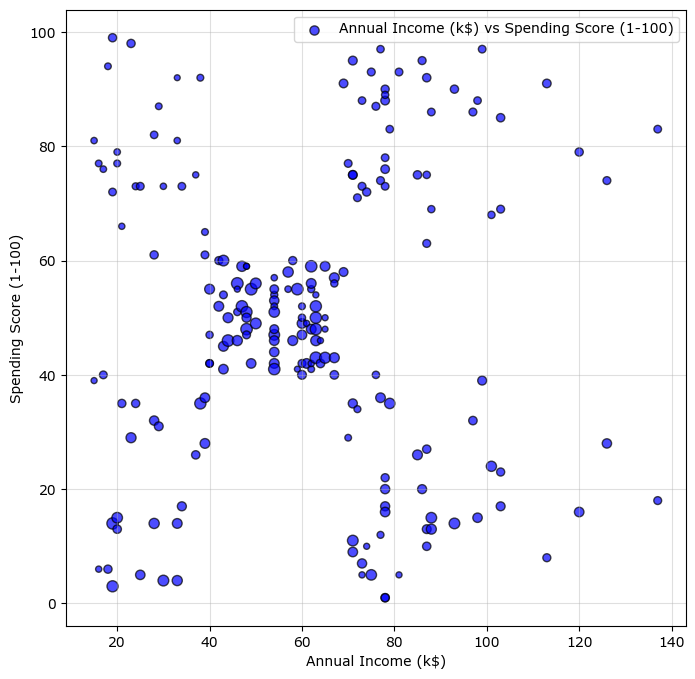

In [7]:
plt.figure( figsize = (8, 8) )

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color = 'b', edgecolor = 'k', alpha = 0.7, s = df['Age'], label = 'Annual Income (k$) vs Spending Score (1-100)')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.grid(True, alpha = 0.4)

plt.legend()

In [8]:
df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# ایدی و جنسیت چون نیاز نداشتم از دیتا فریم اف جدید بر داشتمش

df = df.apply(pd.to_numeric, errors = "coerce")
# تبدیل کردم  NaN ویژگی هارو تبدیل به عدد کردم اگرم نشد به


df = df.dropna(axis = 0)
# دارند (چیزی که عدد نیست در نامپای NaN) NaN پاک کردم سطر هایی که 

x = df.values
# از دیتا فرم به ساختار نامپایی تبدیل کردم اطلاعاتم رو

df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = scaler.fit_transform(x)
# متغیر مستقل رو به عدد هایی تبدیل کردم که انحراف معیارشون صفر شود که اهمیت همه متغیر های مستقل یکی باشه و در یک حدود باشند مقدارشون

In [10]:
from sklearn.cluster import DBSCAN

dbs_can = DBSCAN(eps = 0.5, min_samples = 6)

dbs_can.fit(x)

# مدل رو ساختم :  در  فاصله پنج دهم باید  هفتا نمونه کنارش باشه 

,eps,0.5
,min_samples,6
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [11]:
core_samples_msk = np.zeros_like(dbs_can.labels_, dtype = bool)
core_samples_msk[dbs_can.core_sample_indices_] = True

# اینجا هسته هارو مشخص کردم که در نمودار رسم کنم

In [13]:
n_clusters = len(set(dbs_can.labels_)) - (1 if -1 in dbs_can.labels_ else 0)

print()
print("تعداد خوشه ها : ", n_clusters)
print()

# تعداد گروه ها بدون نویز ها 


تعداد خوشه ها :  5



In [14]:
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(dbs_can.labels_))))

# طیف رنگی نمودار

Text(0, 0.5, 'Spending Score (1-100)')

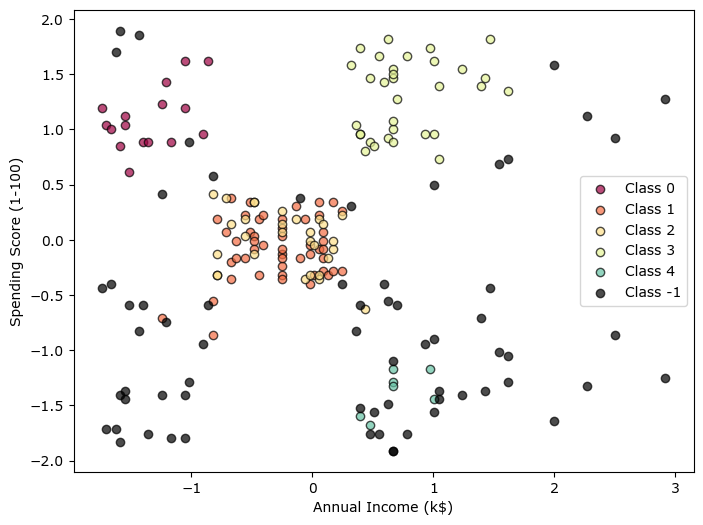

In [16]:
plt.figure( figsize = (8, 6) )

for k, col in zip(set(dbs_can.labels_), colors) :
    
    if k == -1 :
        col = 'k'
        
    class_member_msk = (dbs_can.labels_ == k)
    
    xy = x[class_member_msk & core_samples_msk]
    
    plt.scatter(xy[:, 1], xy[:, 2], c = [col], marker = 'o', alpha = 0.7, edgecolor = 'k', label = f"Class {k}")

    xy = x[class_member_msk & ~core_samples_msk]
    
    plt.scatter(xy[:, 1], xy[:, 2], c = [col], marker = 'o', alpha = 0.7, edgecolor = 'k')
    
plt.legend()

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

In [18]:
from sklearn.metrics import silhouette_score

msk = dbs_can.labels_ != -1

X = x[msk]

print(f"1) silhouette_score: {silhouette_score(X, dbs_can.labels_[msk])}")

# روشی برای فهمیدن اینکه چقدر مدل خوب هست

1) silhouette_score: 0.5277669573360696


In [19]:
df['Class'] = dbs_can.labels_

df.groupby('Class').mean()

# بر اساس گروه دسته بندی کردم و میانگین گرفتم از چیزایی که دارن

,Age,Annual Income (k$),Spending Score (1-100)
Class,,,
-1,39.727273,65.515152,32.303030
0,23.375000,25.312500,78.500000
1,54.240000,53.260000,48.380000
2,24.379310,54.517241,50.172414
3,32.750000,80.875000,83.625000
4,43.857143,78.714286,14.571429


In [21]:
mean = df.groupby(['Class']).mean()
print(mean.index)

Index([-1, 0, 1, 2, 3, 4], dtype='int64', name='Class')


Text(0, 0.5, 'Spending Score (1-100)')

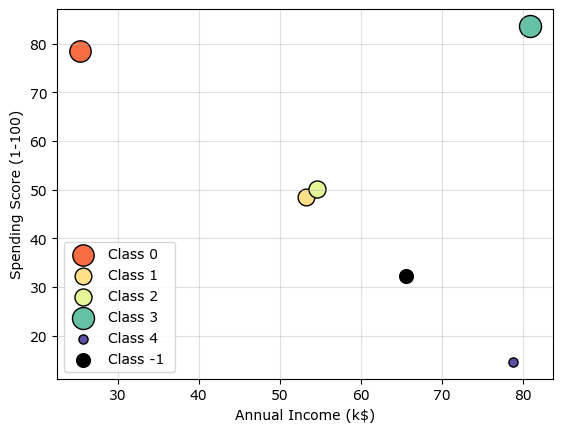

In [26]:
for i, j in zip(mean.index, colors):
    
    if i != -1 :
        size = mean['Spending Score (1-100)'][i] * 3
        plt.scatter(mean['Annual Income (k$)'][i], mean['Spending Score (1-100)'][i], label = f"Class {i}", edgecolor = 'k', color = j, s = size)

plt.scatter(mean['Annual Income (k$)'][-1], mean['Spending Score (1-100)'][-1], label = f"Class -1 ", edgecolor = 'k', color = 'k', s = mean['Spending Score (1-100)'][-1] * 3 )

plt.legend()

plt.grid(True, alpha = 0.4)

plt.xlabel('Annual Income (k$)')

plt.ylabel('Spending Score (1-100)')

# این نمودار همون میانگین رو رسم میکنه که هر گروه یکی رسم میشه که میانگین هست و اندازه هم بر اساس امتیاز کاربر بر اساس رفتار هست